# Credit Risk Analysis Using Machine Learning

In this notebook I will be using some foundational machine learning and data science concepts to explore the problem of credit risk classification.

For example given a person's demographics like age, education, gender and account details like balance, we're going to build a model to predict whether or not it is safe to give loan to the person or not.

## What is classification?
Classification is a type of machine learning problem in which a sample belongs to of the many classes.

It can be binary classification (only two classes), multiclass classification (more than two classes) or multilabel classification (assigning multiple labels to a sample)

## Process
I will be doing the following in this project:
| Step name | What is done |
|:-----|:-----|
| **Exploratory data analysis (EDA)** | Understanding and getting familiar with our dataset |
| **Model training**  | Define and train various models on our chosen dataset|
| **Model evaluation** | Evaluating the performance of our model |
| **Model comparison** | Comparing the different models we have trained to choose the best performing model |
| **Model hyperparameter tuning** | Modifying the hyperparameters of our chosen model to further improve its performance |
| **Feature importance** | This step gives answer to the question "What are the most important features in the dataset" |
| **Cross-validation** | I check if the model works well for unseen data, a good model does. |
| **Reporting what I've found** | Presenting the work to you |

## Tools and libraries used
- Pandas
- Numpy
- Matplotlib
- Scikit-learn

## 1. Going through the 6 step Machine Learning framework

### 1.1 Defining the problem

The problem I will be exploring is a **binary classification** (a sample can belong to one of the two classes) problem.

What I am trying to predict is:

*Given details about a customer or person, can we predict whether or not it is safe to give them a loan?*

### 1.2 The data I am using
Default Payments of Credit Card Clients in Taiwan from 2005

https://raw.githubusercontent.com/MatteoM95/Default-of-Credit-Card-Clients-Dataset-Analisys/refs/heads/main/dataset/default_of_credit_card_clients.csv

(or)

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

The original dataset can be found at https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients from UCI Machine Learning Repository



### 1.3 How the model will be evaluated


Generally accuracy is the starting metric used for classification at the beginning of the project. Over the course, the metric may be updated depending on conditions such as the balance of the target class in the dataset.



### 1.4 Finding the important features

Features are characteristics of the data.

One of the most common ways to do this is to create a **data dictionary**.

#### The Data Dictionary for our dataset

| Feature |Description| Example Values |
| :----------------------------- | :------------------------------------------------------------------------------------------------ | :------------- |
| **ID**                         | ID of each client                                                                                 | 1, 2           |
| **LIMIT_BAL**                  | Amount of given credit in NT dollars (includes individual and family/supplementary credit)        | 20000, 120000  |
| **SEX**                        | Gender (1 = male; 2 = female)                                                                     | 2              |
| **EDUCATION**                  | Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others; 5–6 = unknown) | 2              |
| **MARRIAGE**                   | Marital status (1 = married; 2 = single; 3 = others)                                              | 1, 2           |
| **AGE**                        | Age in years                                                                                      | 24, 26         |
| **PAY_0**                      | Repayment status in September 2005 (-1 = pay duly; 1–9 = months of payment delay)                 | 2, -1          |
| **PAY_2**                      | Repayment status in August 2005 (same scale as above)                                             | 2              |
| **PAY_3**                      | Repayment status in July 2005 (same scale as above)                                               | -1, 2          |
| **PAY_4**                      | Repayment status in June 2005 (same scale as above)                                               | -1, 0          |
| **PAY_5**                      | Repayment status in May 2005 (same scale as above)                                                | -1, 0          |
| **PAY_6**                      | Repayment status in April 2005 (same scale as above)                                              | -1, 0          |
| **BILL_AMT1**                  | Amount of bill statement in September 2005 (NT dollar)                                            | 3913, 2682     |
| **BILL_AMT2**                  | Amount of bill statement in August 2005 (NT dollar)                                               | 3102, 1725     |
| **BILL_AMT3**                  | Amount of bill statement in July 2005 (NT dollar)                                                 | 689, 2682      |
| **BILL_AMT4**                  | Amount of bill statement in June 2005 (NT dollar)                                                 | 0, 3272        |
| **BILL_AMT5**                  | Amount of bill statement in May 2005 (NT dollar)                                                  | 0, 3455        |
| **BILL_AMT6**                  | Amount of bill statement in April 2005 (NT dollar)                                                | 0, 3261        |
| **PAY_AMT1**                   | Amount of previous payment in September 2005 (NT dollar)                                          | 0              |
| **PAY_AMT2**                   | Amount of previous payment in August 2005 (NT dollar)                                             | 689, 1000      |
| **PAY_AMT3**                   | Amount of previous payment in July 2005 (NT dollar)                                               | 0, 1000        |
| **PAY_AMT4**                   | Amount of previous payment in June 2005 (NT dollar)                                               | 0, 1000        |
| **PAY_AMT5**                   | Amount of previous payment in May 2005 (NT dollar)                                                | 0              |
| **PAY_AMT6**                   | Amount of previous payment in April 2005 (NT dollar)                                              | 0, 2000        |
| **default.payment.next.month** | Default payment next month (1 = yes; 0 = no)                                                      | 1              |



## 2. Preparing the tools

Importing the necessary python libraries.
- [pandas](https://pandas.pydata.org/) for data analysis.
- [NumPy](https://numpy.org/) for numerical operations.
- [Matplotlib](https://matplotlib.org/) and [seaborn](https://seaborn.pydata.org/) for plotting or data visualization.
- [Scikit-Learn](https://scikit-learn.org/stable/) for machine learning modelling and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# models
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# fine tuners and evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import RocCurveDisplay

## 3. Loading data
I will be using pandas' read_csv function to load the data as the data is in csv(comma separated values) format.

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/MatteoM95/Default-of-Credit-Card-Clients-Dataset-Analisys/refs/heads/main/dataset/default_of_credit_card_clients.csv')
# df['default payment next month'].value_counts()
df.shape

(30000, 25)

In [ ]:
## glimpse of our data
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Renaming the 'default payment next month' column to target

In [ ]:
df.rename(columns={'default payment next month':'target'}, inplace=True)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 4. EDA (Exploratory Data Analysis)

In this step, we try to familiarize ourselves with the dataset.

We also look for missing values, duplicates, and check the balance of the target column

In [ ]:
### finding the count and percentage of the categorical values in target column
print(df['target'].value_counts())
print("-" * 50)
print("In percentage:")
print(df['target'].value_counts(normalize=True))

target
0    23364
1     6636
Name: count, dtype: int64
--------------------------------------------------
In percentage:
target
0    0.7788
1    0.2212
Name: proportion, dtype: float64


From the above we can say that our dataset is imbalanced with most of samples belonging to class 0 of the target class.

Accuracy is not a good metric for classification problems dealing with imbalanced datasets. Hence we will be using metrics such as recall, precision and f1 score.

<Axes: xlabel='target'>

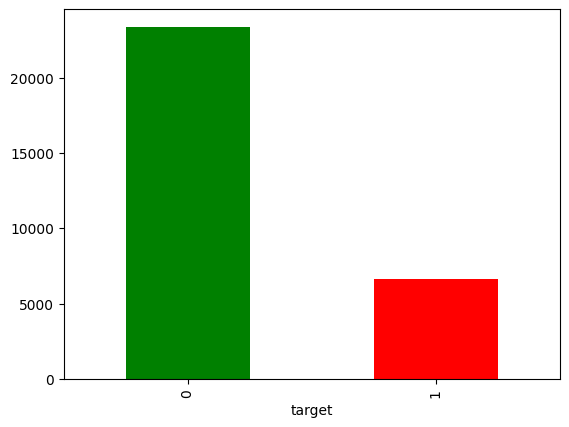

In [ ]:
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])

[`pd.DataFrame.info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html) gives us the number of missing values you have and what type of data are present in the dataset.

In this dataset, there are no missing values and all of our columns are numerical (integer) in nature.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

`describe()` provides a range of metrics about the numerical columns such as mean, standard deviation, min, max etc.

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
# incase the dataset contained any missing values, the below line can be used to find the count of missing values in each column
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


### 4.1 Comparing one feature to another

We will use the pandas' crosstab function to compare the sex and target columns

In [ ]:
pd.crosstab(index=df.target, columns=df.SEX)

SEX,1,2
target,,
0,9015,14349
1,2873,3763


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

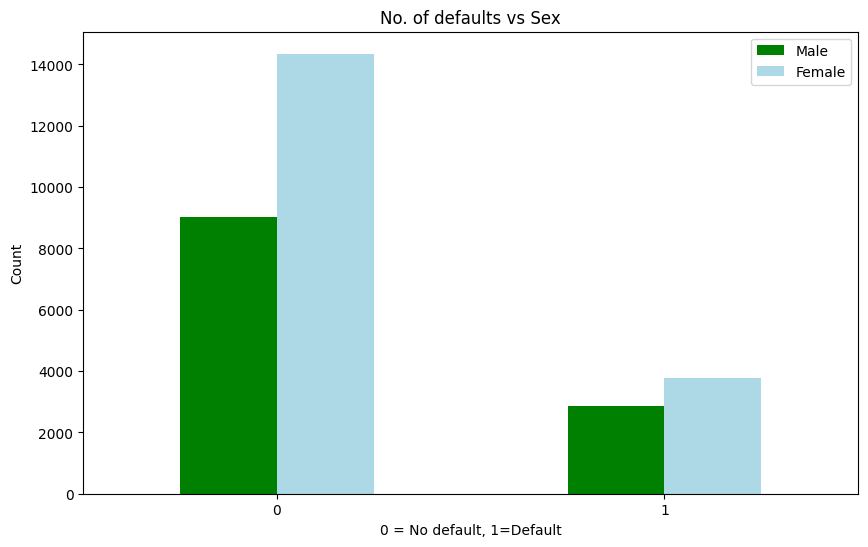

In [ ]:
pd.crosstab(df.target, df.SEX).plot(kind="bar",figsize=(10,6),color=["green", "lightblue"])
plt.title("No. of defaults vs Sex")
plt.xlabel("0 = No default, 1=Default")
plt.ylabel("Count")
plt.legend(["Male", "Female"])
plt.xticks(rotation=0)


### combining different features and compare them with the target variable

Lets try combining age and limit balance

Text(0, 0.5, 'Education')

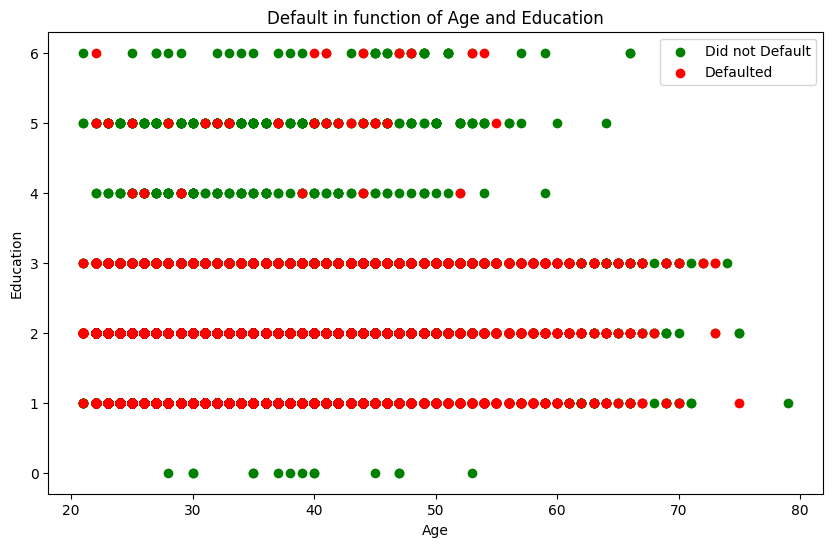

In [ ]:
df.columns

plt.figure(figsize=(10,6))
plt.scatter(df.AGE[df.target==0], df.EDUCATION[df.target==0], c="green")
plt.scatter(df.AGE[df.target==1], df.EDUCATION[df.target==1], c="red")

plt.title("Default in function of Age and Education")
plt.xlabel("Age")
plt.legend(["Did not Default", "Defaulted"])
plt.ylabel("Education")

Looks like most of the defaults happened by people educated

### Correlation between the independent variable

In [ ]:
corr_matrix = df.corr()
corr_matrix

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
ID,1.000000,0.026179,0.018497,0.039177,-0.029079,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
LIMIT_BAL,0.026179,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.018497,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,0.039177,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.029079,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.018678,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.030575,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,...,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.011215,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,...,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.018494,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,...,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.002735,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,...,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614


In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")

## 5. Modeling

In [ ]:
X = df.drop("target", axis=1)

y = df.target.to_numpy()

In [ ]:
X.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,20000,2,2,1,24,2,2,-1,-1,...,689,0,0,0,0,689,0,0,0,0
1,2,120000,2,2,2,26,-1,2,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,3,90000,2,2,2,34,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,4,50000,2,2,1,37,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,5,50000,1,2,1,57,-1,0,-1,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [ ]:
y

array([1, 1, 0, ..., 1, 1, 1])

In [ ]:
### 5.1 Creating a training and test split
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, )

NameError: name 'X' is not defined

### 5.2 Choosing a model

- Logistic Regression - sklearn.linear_model.LogisticRegression()
- K-Nearest Neighbors - sklearn.neighbors.KNeighboursClassifier()
- RandomForest - sklearn.ensemble.RandomForestClassifier()

I have chosen these based on scikit-learn's machine learning roadmap: https://scikit-learn.org/stable/machine_learning_map.html

In [ ]:
models = {"Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'), # max_iter to not get "convergence not reached" warning
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(class_weight='balanced')
          }



In [ ]:
# ## helper function to fit and score the models
# def fit_and_score(models, X_train, X_test, y_train, y_test):
#   np.random.seed(42)

#   model_scores = {}
#   for name, model in models.items():
#     model.fit(X_train, y_train)
#     model_scores[name] = model.score(X_test, y_test) # score function implicitly predicts on X_test and compares those predictions to y_test

#   return model_scores

In [ ]:
from sklearn.metrics import recall_score, f1_score

def fit_and_score(models, X_train, X_test, y_train, y_test):
  np.random.seed(42)

  model_scores = {}
  for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    model_scores[name] = {"recall": recall, "f1": f1}

  return model_scores

In [ ]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': {'recall': 0.6176694592536177,
  'f1': 0.47233546884100175},
 'KNN': {'recall': 0.178979436405179, 'f1': 0.23918575063613232},
 'Random Forest': {'recall': 0.32977913175932977, 'f1': 0.4389254941713127}}

### 5.3 Comparing the results of the three models

<Axes: >

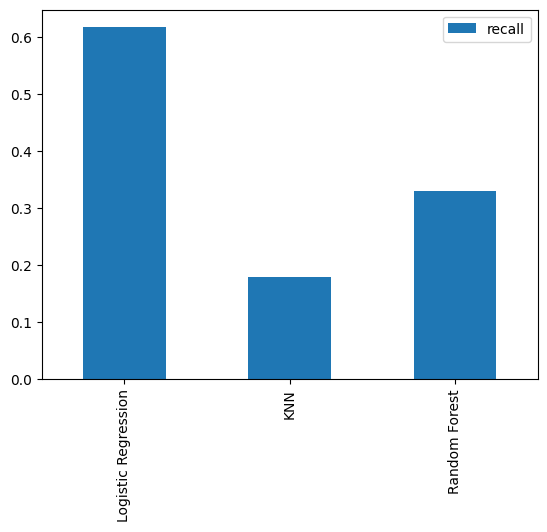

In [ ]:
comparison = pd.DataFrame(model_scores, index=["recall"])
comparison.T.plot.bar()

From the plot we can say that logistic regression performs the best

## 6. Hyperparameter tuning and cross-validation

I will be using k-fold cross validation which involves splitting the data into k splits and then training and testing on each split. We then calculate the average performance.

The following will be done:
1. Hyperparameter tuning
2. Performing cross validation
3. Plotting ROC curves
4. Making a confusion matrix
5. Get the precision, f1 and recall
6. Find the features that are the most important

## 6.1 Tuning the neighbors hyperparameter of the KNN model

Let's try different values for n_neighbors and see the results

In [ ]:
train_scores = []
test_scores = []
neighbors = range(1, 30)

knn = KNeighborsClassifier()

for i in neighbors:
  knn.set_params(n_neighbors = i)

  knn.fit(X_train, y_train)
  train_scores.append(knn.score(X_train, y_train))
  test_scores.append(knn.score(X_test, y_test))


In [ ]:
train_scores

[1.0,
 0.84275,
 0.843625,
 0.8145833333333333,
 0.8155833333333333,
 0.8035833333333333,
 0.803625,
 0.7963333333333333,
 0.7970416666666666,
 0.7924583333333334,
 0.7946666666666666,
 0.791,
 0.7907916666666667,
 0.7892916666666666,
 0.7892083333333333,
 0.7877083333333333,
 0.7878333333333334,
 0.7860416666666666,
 0.7860416666666666,
 0.7855416666666667,
 0.7865416666666667,
 0.7856666666666666,
 0.7851666666666667,
 0.784875,
 0.7851666666666667,
 0.7840416666666666,
 0.7840416666666666,
 0.7832916666666667,
 0.783875]

### Plotting the values for better understanding

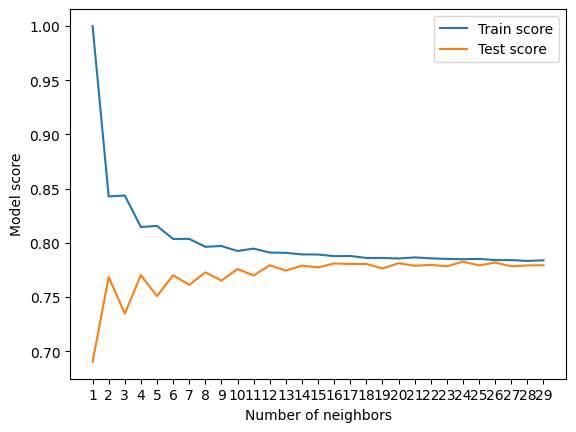

In [ ]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1,30))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

From the above we can see that n_neighbors = 16 gives the best results

## 6.2 Tuning with RandomizedSearchCV

Rather than trying various hyperparameters manually, RandomizedSearchCV tries a number of different combinations, evaluates and stores the best.

In [ ]:
### logistic regression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver":["liblinear"]}

### randomforest classifier hyperparameters
random_forest_grid = {"n_estimators": np.arange(10, 1000, 50),
                      "max_depth": [None, 3, 5, 10],
                      "min_samples_split": np.arange(2, 20, 2),
                      "min_samples_leaf": np.arange(1, 20, 2)}

In [ ]:
%%time
np.random.seed(42)

# setting up random hyperparameter search for logistic regression
rs_lr = RandomizedSearchCV(LogisticRegression(),
                           param_distributions=log_reg_grid,
                           cv=5,
                           n_iter = 20,
                           verbose=True)
rs_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: user 25.4 s, sys: 34.9 ms, total: 25.4 s
Wall time: 25.6 s


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [ ]:
rs_lr.best_params_

{'solver': 'liblinear', 'C': np.float64(0.0001)}

In [ ]:
rs_lr.score(X_test, y_test)

0.7811666666666667

looks like the accuracy reduced

### doing similarly for random forest

In [ ]:
%%time
np.random.seed(42)

# setting up random hyperparameter search for logistic regression
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=random_forest_grid,
                           cv=5,
                           n_iter = 20,
                           verbose=True)
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
rs_rf.best_params_

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

In [ ]:
rs_rf.score(X_test, y_test)

## 6.3 Tuning with GridSearchCV
The difference between RandomSearchCV and GridSearchCV is that RandomSearchCV explores random combination of hyperparameters from the grid of parameters for a fixed number of iterations, where as, GridSearchCV goes through every possible combination of hyperparameters from the grid.

**NOTE**: GridSearchCV can take very long time, so be patient.

In [ ]:
%%time
log_reg_grid= {"C": np.logspace(-4, 4, 20),
               "solver": ["liblinear"]}

gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid = log_reg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
CPU times: user 25.1 s, sys: 22.4 ms, total: 25.1 s
Wall time: 25.3 s


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [ ]:
gs_log_reg.best_params_

{'C': np.float64(0.0001), 'solver': 'liblinear'}

In [ ]:
gs_log_reg.score(X_test, y_test)

0.7811666666666667

## 7. Evaluating a classification model using more than just accuracy

Few metrics that can be used for evaluating classification models

- ROC curve and AUC score
- Confusion matrix
- Classification report
- Precision
- Recall
- F1-score

In [ ]:
# # Make preidctions on test data
# y_preds = gs_log_reg.predict(X_test)

In [ ]:
y_preds

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

## 7.1 ROC Curve and AUC Scores
ROC curve is a way of understanding how the model is performing by comparing  the true positive rate to the false positive rate.

The ROC of a guessing model would be a line going from the bottom left corner to the top right corner and have an AUC = 0.5.

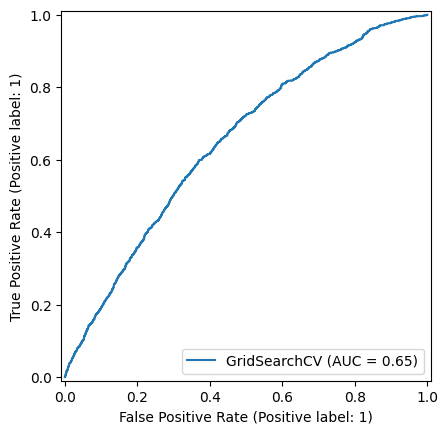

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(estimator = gs_log_reg,
                               X=X_test,
                               y= y_test) # the grid search tuned log reg


In [ ]:
## 7.2 Confusion Matrix
print(confusion_matrix(y_test, y_preds))

[[4687    0]
 [1313    0]]


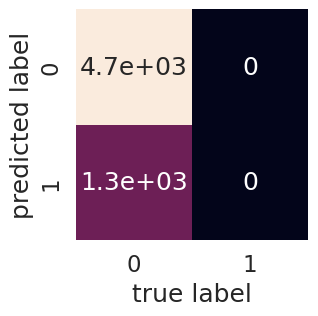

In [ ]:
### visualizing the confusion matrix with seaborn
sns.set(font_scale = 1.5)

def plot_confusion_matrix(y_test, y_preds):
  fig, ax = plt.subplots(figsize = (3,3))
  ax = sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, cbar=False)
  plt.xlabel("true label")
  plt.ylabel("predicted label")

plot_confusion_matrix(y_test, y_preds)

In [ ]:
### 7.3 Classification report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### now lets calculate the metrics using cross validation using cross_val_score

In [ ]:
gs_log_reg.best_params_

{'C': np.float64(0.0001), 'solver': 'liblinear'}

In [ ]:
from sklearn.model_selection import cross_val_score

# classifier with best hyperparameters found with GridSearchCV
clf = LogisticRegression(C = 0.615848211066026, solver="liblinear", class_weight="balanced")



In [ ]:
%%time

# cross validation accuracy score
cv_acc = cross_val_score(clf, X, y, cv = 5, scoring="accuracy")
cv_acc

CPU times: user 6.58 s, sys: 7.75 ms, total: 6.58 s
Wall time: 6.63 s


array([0.60933333, 0.64733333, 0.605     , 0.70366667, 0.7645    ])

In [ ]:
cv_acc = np.mean(cv_acc)
cv_acc

np.float64(0.6659666666666666)

In [ ]:
cv_precision = np.mean(cross_val_score(clf, X, y, cv=5, scoring="precision"))
cv_precision

np.float64(0.3663958042434315)

In [ ]:
cv_recall = np.mean(cross_val_score(clf, X, y, cv=5, scoring="recall"))
cv_recall

np.float64(0.6255311373602928)

In [ ]:
cv_f1 = np.mean(cross_val_score(clf, X, y, cv=5, scoring="f1"))
cv_f1

np.float64(0.45718408383407916)

<Axes: title={'center': 'Cross-Validated Metrics'}>

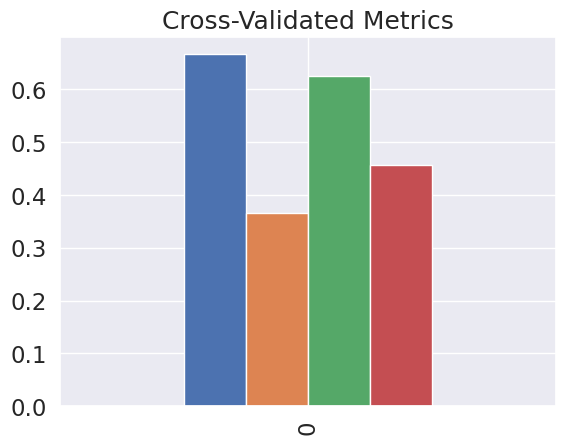

In [ ]:
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1": cv_f1}, index=[0])
cv_metrics.plot.bar(title="Cross-Validated Metrics", legend=False)

## 8. Feature Importance
We wish to find the most important features

In [ ]:
clf = LogisticRegression(C = 0.615848211066026, solver="liblinear", class_weight="balanced")

In [ ]:
clf.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
y_preds = clf.predict(X_test)


In [ ]:
# coef_ attribute is the coefficient of the features in the decision function.
clf.coef_

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

The above values represent how much each feature contributes how the model makes a decision of whether the sample leans towards the person defaulting or not

In [ ]:
# Matching features to columns
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
features_dict

{'ID': np.float64(-2.5117519052142884e-05),
 'LIMIT_BAL': np.float64(-4.01000262815599e-06),
 'SEX': np.float64(-5.293184397226777e-05),
 'EDUCATION': np.float64(-5.872796081080333e-05),
 'MARRIAGE': np.float64(-5.6715098067117464e-05),
 'AGE': np.float64(-0.00071867601915428),
 'PAY_0': np.float64(0.00014272319222074102),
 'PAY_2': np.float64(0.00011343631040718706),
 'PAY_3': np.float64(9.808217465470339e-05),
 'PAY_4': np.float64(9.229053845766132e-05),
 'PAY_5': np.float64(8.181934710305151e-05),
 'PAY_6': np.float64(7.58426453363909e-05),
 'BILL_AMT1': np.float64(-8.823337181418188e-06),
 'BILL_AMT2': np.float64(4.674747574212788e-06),
 'BILL_AMT3': np.float64(2.2110562612085365e-06),
 'BILL_AMT4': np.float64(2.116842705401042e-06),
 'BILL_AMT5': np.float64(2.041207703712504e-06),
 'BILL_AMT6': np.float64(1.919226101621374e-06),
 'PAY_AMT1': np.float64(-2.6475236144586903e-05),
 'PAY_AMT2': np.float64(-2.2523090722852724e-05),
 'PAY_AMT3': np.float64(-7.193163326375927e-06),
 'PAY

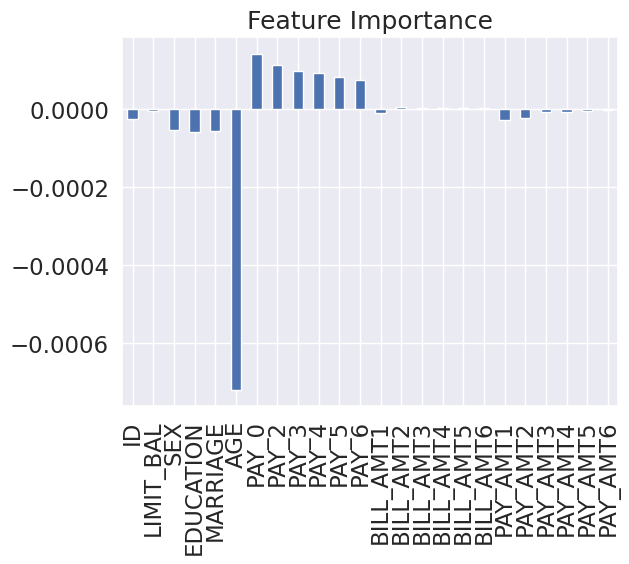

In [ ]:
# Visualizing feature importance
features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.plot.bar(title="Feature Importance", legend=False);

The larger the value the more the feature contributes to the models decision.

In [ ]:
pd.crosstab(df["SEX"], df["target"])

target,0,1
SEX,,
1,9015,2873
2,14349,3763


### The below is still in progress

To Do: Check catboost and xgboost


In [ ]:
import joblib

FEATURE_ORDER = list(X.columns)

joblib.dump({
    "model": clf,
    "features": FEATURE_ORDER
}, "model.pkl")

In [ ]:
## selective retraining
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import joblib

df = pd.read_csv(
    "https://raw.githubusercontent.com/MatteoM95/Default-of-Credit-Card-Clients-Dataset-Analisys/refs/heads/main/dataset/default_of_credit_card_clients.csv"
)

df.rename(columns={"default payment next month": "target"}, inplace=True)

selected_features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_AMT1",
    "PAY_AMT2"
]

X = df[selected_features]
y = df["target"]

print("Selected Features:", selected_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(
    C=0.615848211066026,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("\nF1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


importance = dict(zip(selected_features, model.coef_[0]))
importance = {k: abs(v) for k, v in importance.items()}

print("\nFeature Importance:")
for k, v in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{k}: {v}")


joblib.dump(
    {
        "model": model,
        "features": selected_features
    },
    "model.pkl"
)

print("\nModel saved as model.pkl")


Selected Features: ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_AMT1', 'PAY_AMT2']

F1 Score: 0.4095578383206789

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.52      0.65      4687
           1       0.29      0.70      0.41      1313

    accuracy                           0.56      6000
   macro avg       0.58      0.61      0.53      6000
weighted avg       0.74      0.56      0.60      6000


Feature Importance:
AGE: 0.015274539259049114
PAY_0: 0.0030157550454031875
PAY_2: 0.002472059888257033
PAY_AMT2: 1.191593414066946e-05
PAY_AMT1: 1.1780209185281196e-05
LIMIT_BAL: 2.8950222116065387e-06

Model saved as model.pkl
